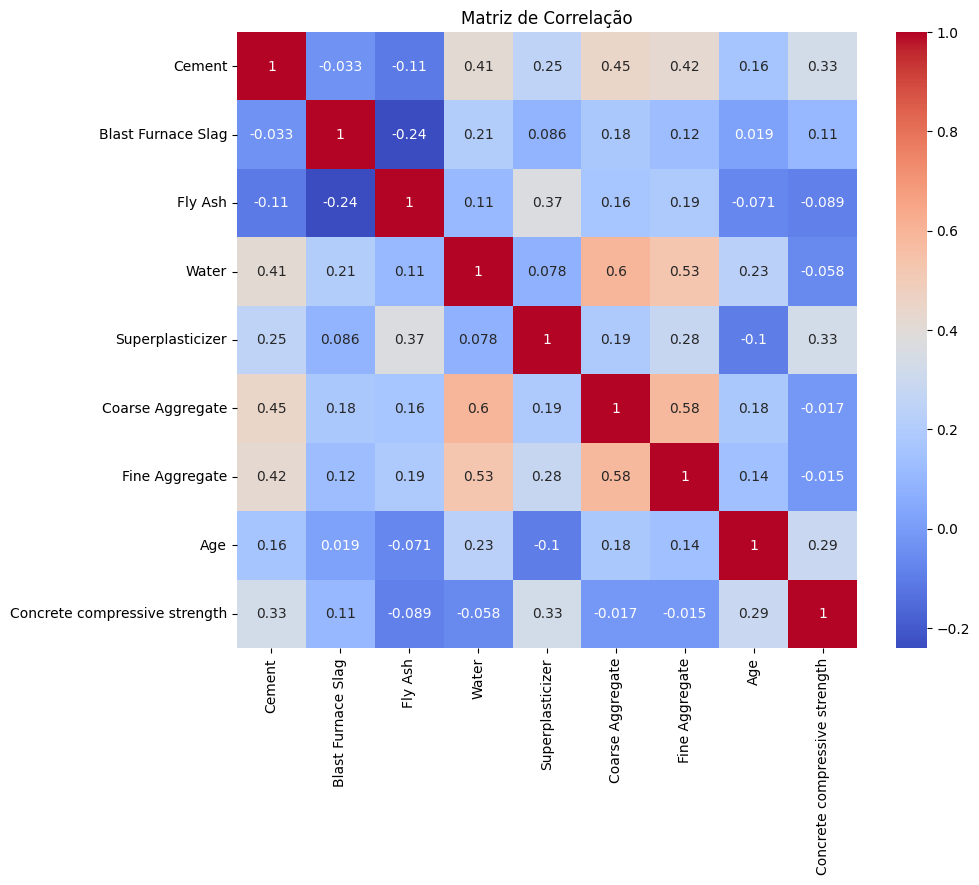

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("dados_concreto_-_Sheet1.csv")

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

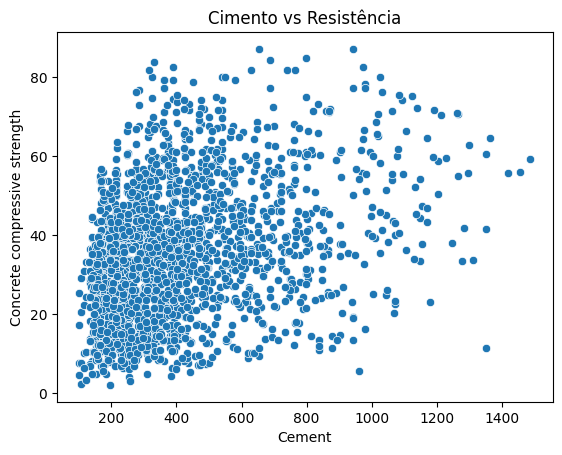

In [ ]:
sns.scatterplot(x="Cement", y="Concrete compressive strength", data=df)
plt.title("Cimento vs Resistência")
plt.show()


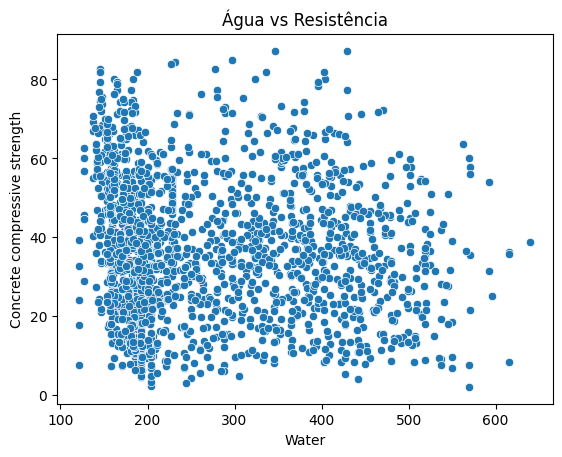

In [ ]:
sns.scatterplot(x="Water", y="Concrete compressive strength", data=df)
plt.title("Água vs Resistência")
plt.show()


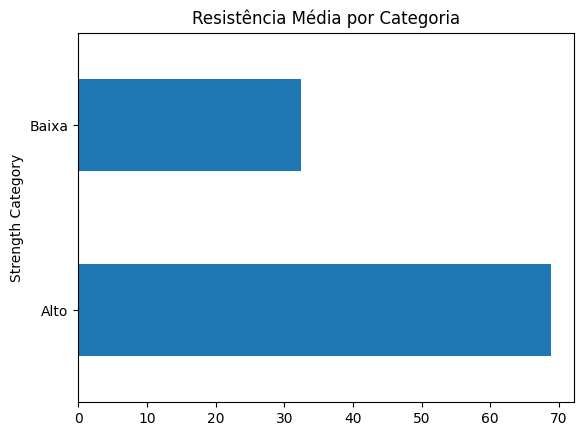

In [ ]:
df.groupby("Strength Category")["Concrete compressive strength"].mean().plot(
    kind="barh"
)
plt.title("Resistência Média por Categoria")
plt.show()


In [ ]:
df.isnull().sum()


,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Concrete compressive strength,9
Strength Category,0


In [ ]:
df['Concrete compressive strength'] = df['Concrete compressive strength'].fillna(df['Concrete compressive strength'].mean())

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Concrete compressive strength', axis=1)
y = df['Concrete compressive strength']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest R²:", r2_rf)
print("Random Forest MAE:", mae_rf)


Random Forest R²: 0.8082041693750641
Random Forest MAE: 5.259736647772802


In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


In [ ]:
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression R²:", r2_lr)
print("Linear Regression MAE:", mae_lr)


Linear Regression R²: 0.5133782726163139
Linear Regression MAE: 9.195907237293891


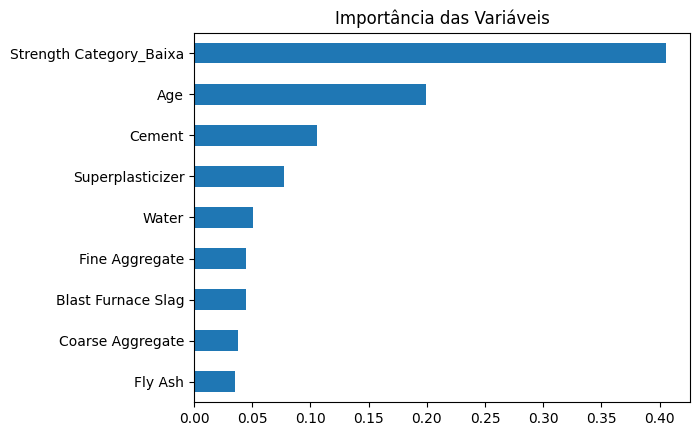

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh")
plt.title("Importância das Variáveis")
plt.show()


In [ ]:
novo_concreto = pd.DataFrame([{
    "Cement": 550,
    "Blast Furnace Slag": 150,
    "Fly Ash": 0,
    "Water": 180,
    "Superplasticizer": 2.5,
    "Coarse Aggregate": 1000,
    "Fine Aggregate": 700,
    "Age": 25,
    "Strength Category_Baixa": 0
}])

novo_concreto = novo_concreto[X.columns]

predicao = rf.predict(novo_concreto)

print("Resistência prevista:", predicao[0], "MPa")

Resistência prevista: 70.98334999999992 MPa
